# A Python-Based Analysis of Walmart Weekly Sales: Store Performance, Holiday Effects, and Economic Factors

## Problem Definition
This project analyses Walmart weekly sales data to understand how store differences, holiday periods, and selected economic factors affect sales performance.

## Intended User
The intended users are retail managers, beginner business analysts, and students who want to understand store-level sales patterns and the factors affecting retail performance.

## Analytical Questions
1. Which Walmart stores achieved the highest weekly sales overall?
2. How did weekly sales change over time?
3. Did holiday weeks produce higher sales than non-holiday weeks?
4. Are weekly sales related to temperature, fuel price, CPI, or unemployment?
5. What business insights can be drawn from these patterns?

## Data Source
Dataset name: Walmart Sales Dataset  
Original source: Kaggle, Walmart Sales Forecast Dataset  
Source link: https://www.kaggle.com/datasets/mikhail1681/walmart-sales
Access date: 21 April 2026

## Dataset Overview
The dataset contains weekly sales records for 45 Walmart stores from 2010-02-05 to 2012-10-26.

Main variables:
- Store: store identifier
- Date: week date
- Weekly_Sales: weekly sales revenue
- Holiday_Flag: whether the week contains a holiday
- Temperature: weekly temperature
- Fuel_Price: weekly fuel price
- CPI: consumer price index
- Unemployment: unemployment rate

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
df = pd.read_csv("data/Walmart_Sales.csv")
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [3]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


The dataset contains weekly sales observations at the store level. Before analysis, the date column needs to be converted into datetime format, and the dataset should be checked for missing values and duplicates.

In [4]:
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")

In [7]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()
df["YearMonth"] = df["Date"].dt.to_period("M").astype(str)

In [8]:
df.dtypes

Store                    int64
Date            datetime64[ns]
Weekly_Sales           float64
Holiday_Flag             int64
Temperature            float64
Fuel_Price             float64
CPI                    float64
Unemployment           float64
Year                     int32
Month                    int32
Month_Name              object
YearMonth               object
dtype: object

In [9]:
df.describe()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month
count,6435.000000,6435,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,2011-06-17 00:00:00,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151,2010.965035,6.447552
min,1.000000,2010-02-05 00:00:00,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000,2010.000000,1.000000
25%,12.000000,2010-10-08 00:00:00,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000,2010.000000,4.000000
50%,23.000000,2011-06-17 00:00:00,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000,2011.000000,6.000000
75%,34.000000,2012-02-24 00:00:00,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000,2012.000000,9.000000
max,45.000000,2012-10-26 00:00:00,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000,2012.000000,12.000000
std,12.988182,NaN,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885,0.797019,3.238308


The dataset does not contain missing values or duplicates. The Date column was converted into datetime format, and new time-related variables were created to support trend analysis. These preparation steps make the dataset easier to analyse by month and year.

## Overall Sales Overview

In [10]:
total_sales = df["Weekly_Sales"].sum()
average_sales = df["Weekly_Sales"].mean()
max_sales = df["Weekly_Sales"].max()
min_sales = df["Weekly_Sales"].min()

print("Total sales:", total_sales)
print("Average weekly sales:", average_sales)
print("Maximum weekly sales:", max_sales)
print("Minimum weekly sales:", min_sales)

Total sales: 6737218987.11
Average weekly sales: 1046964.8775617715
Maximum weekly sales: 3818686.45
Minimum weekly sales: 209986.25


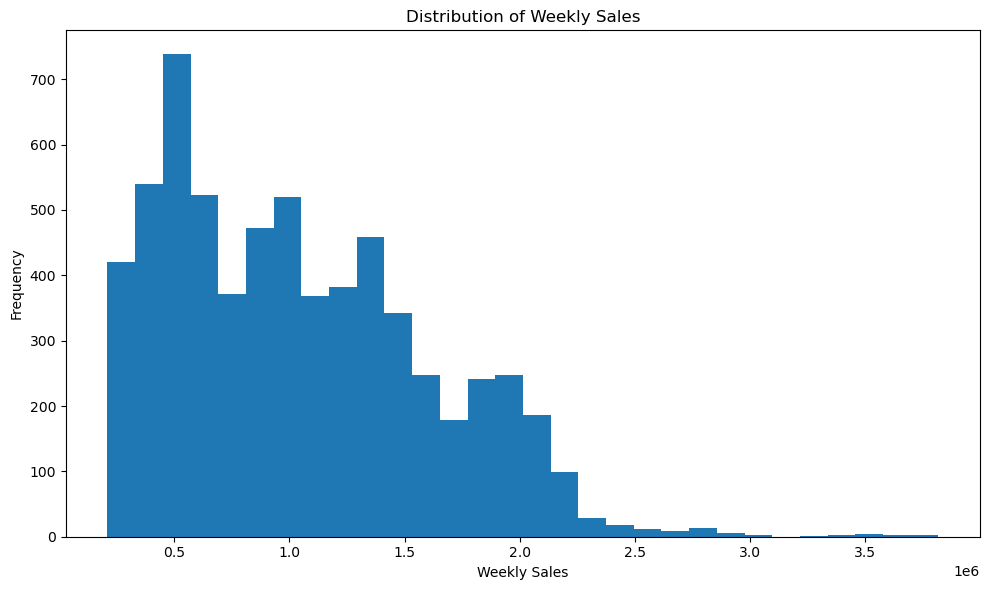

In [11]:
plt.hist(df["Weekly_Sales"], bins=30)
plt.title("Distribution of Weekly Sales")
plt.xlabel("Weekly Sales")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Weekly sales vary substantially across observations, suggesting strong differences between stores or periods. This indicates that further analysis by store and by time is necessary.

## Store Performance Analysis

In [12]:
store_sales = df.groupby("Store")["Weekly_Sales"].sum().sort_values(ascending=False)
store_sales.head(10)

Store
20    3.013978e+08
4     2.995440e+08
14    2.889999e+08
13    2.865177e+08
2     2.753824e+08
10    2.716177e+08
27    2.538559e+08
6     2.237561e+08
1     2.224028e+08
39    2.074455e+08
Name: Weekly_Sales, dtype: float64

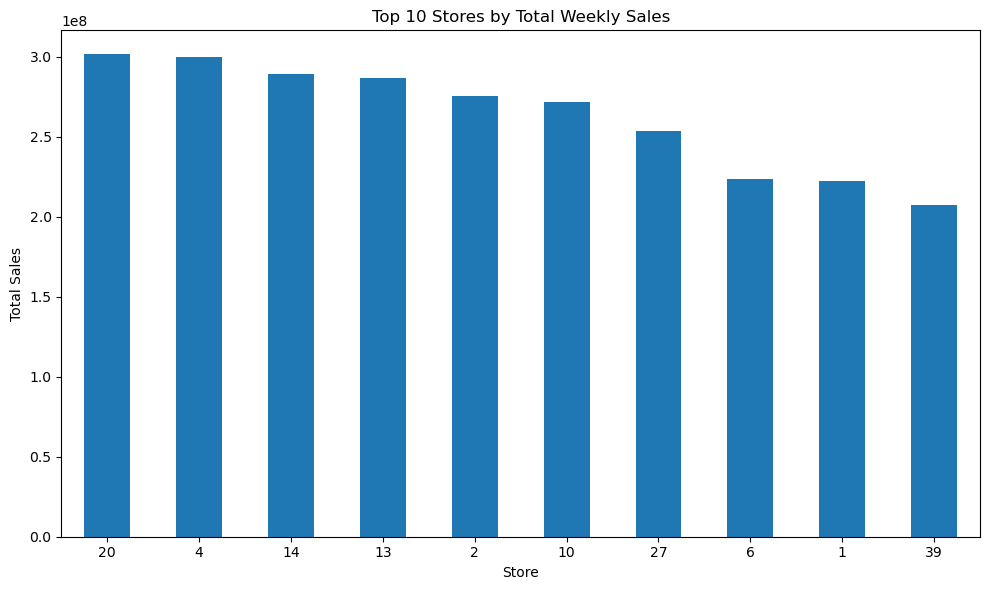

In [13]:
top10_stores = store_sales.head(10)

top10_stores.plot(kind="bar")
plt.title("Top 10 Stores by Total Weekly Sales")
plt.xlabel("Store")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("figures/top10_stores.png")
plt.show()

In [14]:
store_avg_sales = df.groupby("Store")["Weekly_Sales"].mean().sort_values(ascending=False)
store_avg_sales.head(10)

Store
20    2.107677e+06
4     2.094713e+06
14    2.020978e+06
13    2.003620e+06
2     1.925751e+06
10    1.899425e+06
27    1.775216e+06
6     1.564728e+06
1     1.555264e+06
39    1.450668e+06
Name: Weekly_Sales, dtype: float64

In [15]:
store_std_sales = df.groupby("Store")["Weekly_Sales"].std().sort_values(ascending=False)
store_std_sales.head(10)

Store
14    317569.949476
10    302262.062504
20    275900.562742
4     266201.442297
13    265506.995776
23    249788.038068
27    239930.135688
2     237683.694682
39    217466.454833
6     212525.855862
Name: Weekly_Sales, dtype: float64

In [16]:
store_total = df.groupby("Store")["Weekly_Sales"].sum().sort_values(ascending=False)
top5 = store_total.head(5)
bottom5 = store_total.tail(5)

comparison = pd.concat([top5, bottom5])
comparison

Store
20    3.013978e+08
4     2.995440e+08
14    2.889999e+08
13    2.865177e+08
2     2.753824e+08
38    5.515963e+07
36    5.341221e+07
5     4.547569e+07
44    4.329309e+07
33    3.716022e+07
Name: Weekly_Sales, dtype: float64

Top stores may deserve replication of best practices, while bottom stores may require operational review.

Store-level analysis shows that some stores consistently generated much higher weekly sales than others. At the same time, some stores also displayed higher sales volatility, suggesting that strong performance may come with less stability.

## Time Trend and Seasonality

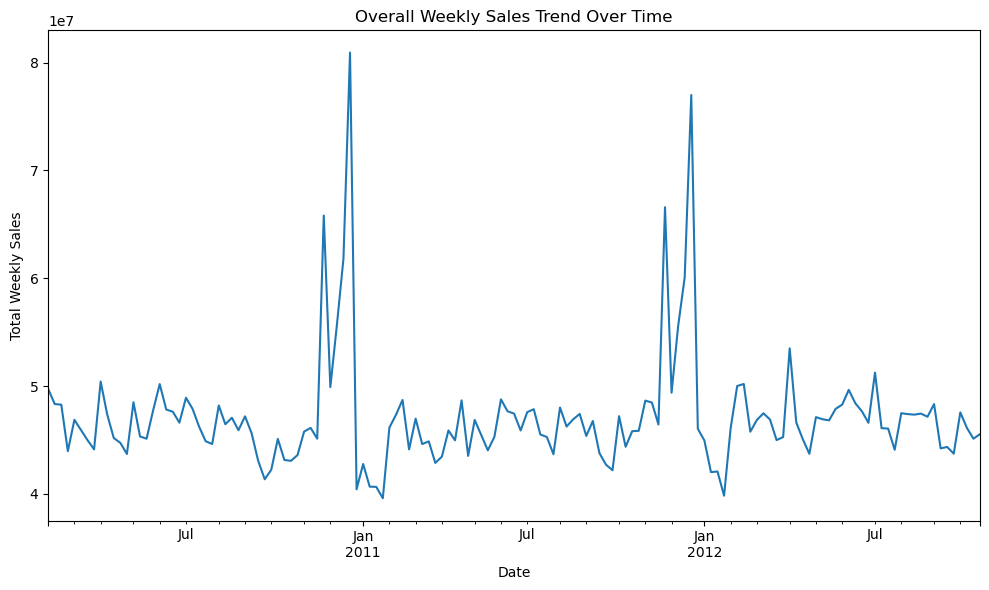

In [17]:
weekly_trend = df.groupby("Date")["Weekly_Sales"].sum()

weekly_trend.plot()
plt.title("Overall Weekly Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Total Weekly Sales")
plt.tight_layout()
plt.savefig("figures/overall_trend.png")
plt.show()

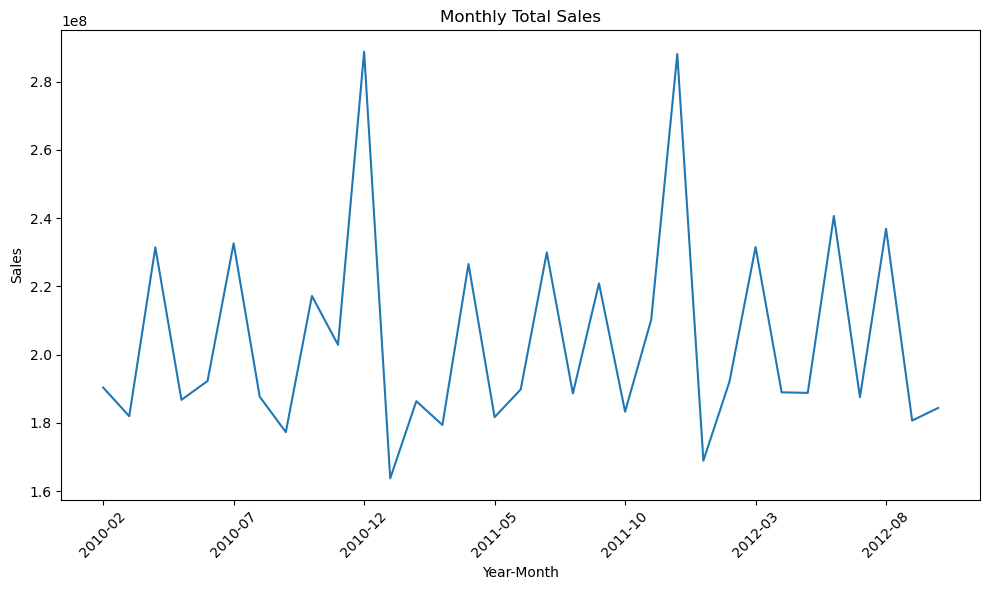

In [18]:
monthly_sales = df.groupby("YearMonth")["Weekly_Sales"].sum()

monthly_sales.plot()
plt.title("Monthly Total Sales")
plt.xlabel("Year-Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("figures/monthly_sales.png")
plt.show()

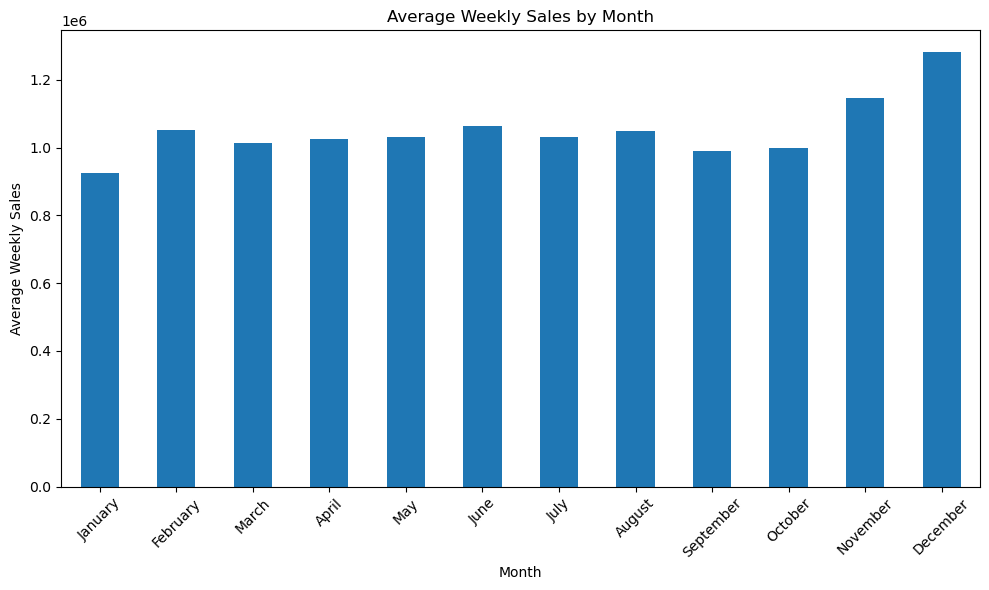

In [19]:
monthly_pattern = df.groupby("Month_Name")["Weekly_Sales"].mean()

month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]
monthly_pattern = monthly_pattern.reindex(month_order)

monthly_pattern.plot(kind="bar")
plt.title("Average Weekly Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Weekly Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Sales changed over time rather than remaining constant. The monthly analysis suggests that some months had stronger average weekly sales than others, which may indicate seasonal demand patterns.

## Holiday Effect

In [20]:
holiday_sales = df.groupby("Holiday_Flag")["Weekly_Sales"].agg(["mean", "sum", "count"])
holiday_sales

,mean,sum,count
Holiday_Flag,,,
0,1.041256e+06,6.231919e+09,5985
1,1.122888e+06,5.052996e+08,450


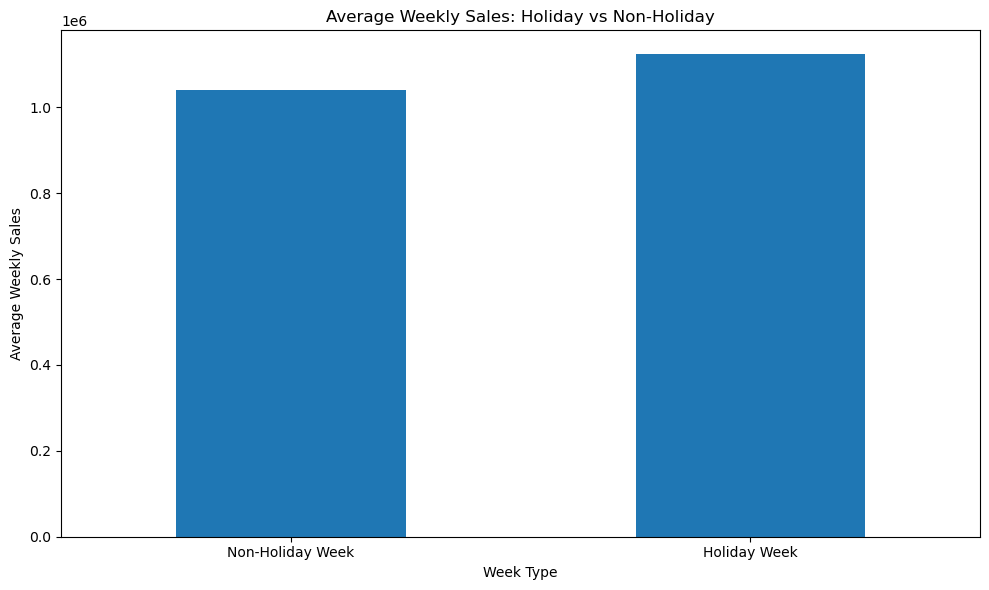

In [21]:
holiday_labels = {0: "Non-Holiday Week", 1: "Holiday Week"}
holiday_mean = df.groupby("Holiday_Flag")["Weekly_Sales"].mean()
holiday_mean.index = [holiday_labels[i] for i in holiday_mean.index]

holiday_mean.plot(kind="bar")
plt.title("Average Weekly Sales: Holiday vs Non-Holiday")
plt.xlabel("Week Type")
plt.ylabel("Average Weekly Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("figures/holiday_vs_nonholiday.png")
plt.show()

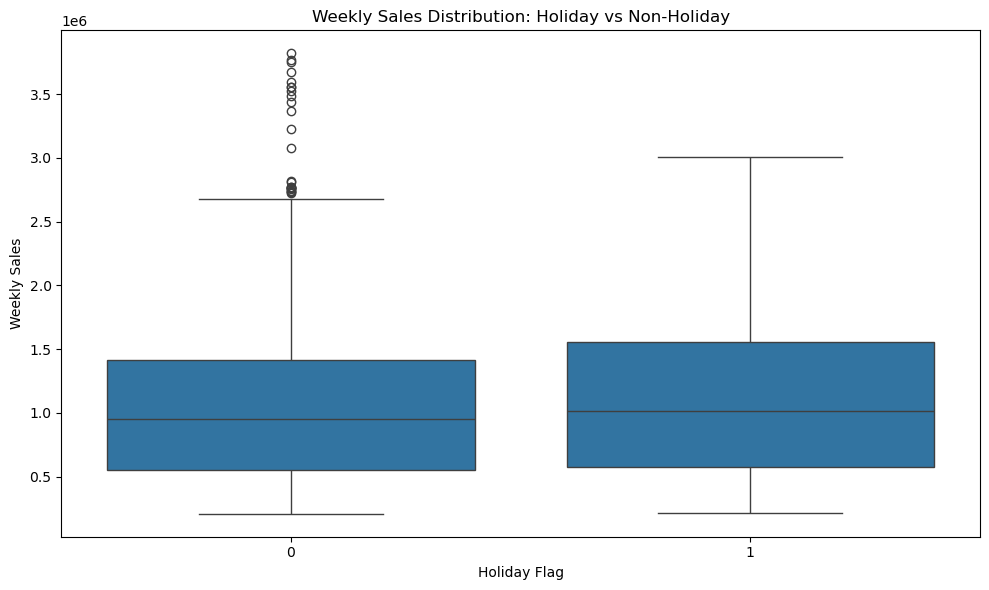

In [22]:
sns.boxplot(x="Holiday_Flag", y="Weekly_Sales", data=df)
plt.title("Weekly Sales Distribution: Holiday vs Non-Holiday")
plt.xlabel("Holiday Flag")
plt.ylabel("Weekly Sales")
plt.tight_layout()
plt.show()

Not only do average sales differ, but holiday weeks also show higher variability in sales.

Holiday weeks tend to show different sales behaviour compared with non-holiday weeks. This suggests that holiday periods may affect consumer demand and should be considered in retail planning.

## Economic Factors

In [23]:
corr = df[["Weekly_Sales", "Temperature", "Fuel_Price", "CPI", "Unemployment"]].corr()
corr

,Weekly_Sales,Temperature,Fuel_Price,CPI,Unemployment
Weekly_Sales,1.000000,-0.063810,0.009464,-0.072634,-0.106176
Temperature,-0.063810,1.000000,0.144982,0.176888,0.101158
Fuel_Price,0.009464,0.144982,1.000000,-0.170642,-0.034684
CPI,-0.072634,0.176888,-0.170642,1.000000,-0.302020
Unemployment,-0.106176,0.101158,-0.034684,-0.302020,1.000000


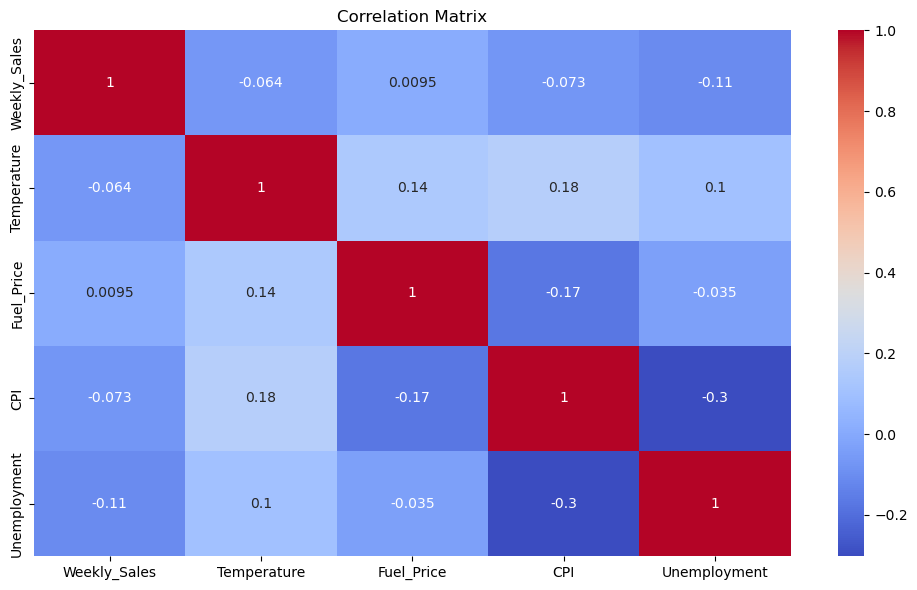

In [24]:
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig("figures/correlation_heatmap.png")
plt.show()

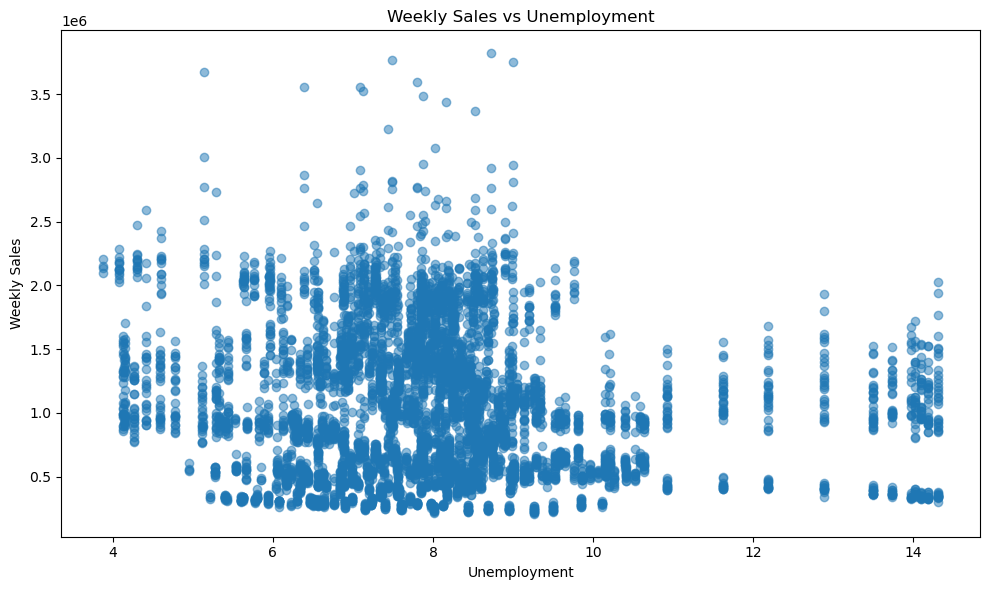

In [25]:
plt.scatter(df["Unemployment"], df["Weekly_Sales"], alpha=0.5)
plt.title("Weekly Sales vs Unemployment")
plt.xlabel("Unemployment")
plt.ylabel("Weekly Sales")
plt.tight_layout()
plt.savefig("figures/scatter_unemployment_sales.png")
plt.show()

The correlations between weekly sales and the selected economic variables appear limited or mixed. This suggests that store-level and seasonal factors may be more important than macroeconomic variables in explaining short-term weekly sales differences in this dataset.

## Key Findings

1. Sales performance differed significantly across stores, with some stores consistently generating much higher total and average weekly sales.
2. Weekly sales changed over time, suggesting that retail performance was not stable across the full period.
3. Holiday weeks showed different average sales from non-holiday weeks, indicating that holiday timing may affect customer demand.
4. The selected economic factors showed only limited or mixed relationships with weekly sales.
5. For retail managers, store-level strategy and time-based planning may be more important than relying only on broad economic indicators.

## Limitations

- The dataset does not include product categories, customer segments, or regional information, so the analysis is limited to store-level sales patterns.
- The analysis focuses mainly on descriptive statistics and simple relationships rather than advanced forecasting models.
- Correlation does not imply causation, so the observed relationships should be interpreted carefully.
- The original dataset source should be documented clearly for reproducibility.

## Conclusion

This project used Python to analyse Walmart weekly sales data from multiple perspectives, including store performance, time trends, holiday effects, and economic indicators. The results show that store differences and timing patterns play an important role in retail sales performance. The project demonstrates how a simple but structured Python workflow can produce useful business insights for beginner retail analysis.

In [26]:
summary_table = pd.DataFrame({
    "Metric": [
        "Highest total sales store",
        "Highest average weekly sales store",
        "Holiday week average sales",
        "Non-holiday week average sales"
    ],
    "Value": [
        store_total.idxmax(),
        df.groupby("Store")["Weekly_Sales"].mean().idxmax(),
        df[df["Holiday_Flag"] == 1]["Weekly_Sales"].mean(),
        df[df["Holiday_Flag"] == 0]["Weekly_Sales"].mean()
    ]
})
summary_table

,Metric,Value
0,Highest total sales store,2.000000e+01
1,Highest average weekly sales store,2.000000e+01
2,Holiday week average sales,1.122888e+06
3,Non-holiday week average sales,1.041256e+06


## Limitations and Next Steps

This analysis is limited by the variables available in the dataset. The dataset only covers 45 stores over a 2.5-year period, which may not be representative of all Walmart stores or current market conditions.

Future work could include:
- Forecasting future sales using time series models
- Clustering stores based on performance patterns
- Analyzing additional retail variables such as promotions, product categories, and regional information
- Incorporating external factors like competitor activity or online sales data